In [1]:
# Notebook 05: Forecasting & Final Results
# BEFORE: We have a trained model but no future predictions
# OPERATION: Load best model and forecast future energy demand
# WHY this is the final step:
#   All previous notebooks built towards this moment
#   Cleaning → EDA → Modeling → now Forecasting
#   This is what smart grid operators actually need —
#   not just understanding past demand but predicting future demand

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
warnings.filterwarnings('ignore')

from pycaret.regression import load_model, predict_model

PROCESSED_PATH = os.path.join('..', 'data', 'processed')
EXPORTS_PATH   = os.path.join('..', 'exports')

# Load cleaned data
posoco = pd.read_csv(
    os.path.join(PROCESSED_PATH, 'posoco_cleaned.csv'),
    parse_dates=True, index_col='Date'
)

# Load saved best model
best_model = load_model(os.path.join(EXPORTS_PATH, 'best_energy_model'))

print(f"POSOCO shape : {posoco.shape}")
print(f"Model loaded : {type(best_model).__name__}")
print(" Ready for forecasting")

Transformation Pipeline and Model Successfully Loaded
POSOCO shape : (4828, 138)
Model loaded : Pipeline
 Ready for forecasting


In [2]:
# BEFORE: Raw posoco data — needs same features as training
# OPERATION: Recreate exact same features used in Notebook 04
# WHY exact same features:
#   Model was trained on specific features
#   If we give different features at prediction time — model crashes
#   This is called feature consistency — critical rule in ML

df = posoco.copy()

df['Year']      = df.index.year
df['Month']     = df.index.month
df['Day']       = df.index.day
df['DayOfWeek'] = df.index.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['Quarter']   = df.index.quarter
df['DayOfYear'] = df.index.dayofyear

df['Lag_7']  = df['India: DemandMet'].shift(7)
df['Lag_30'] = df['India: DemandMet'].shift(30)
df['Rolling_7d']  = df['India: DemandMet'].rolling(7).mean()
df['Rolling_30d'] = df['India: DemandMet'].rolling(30).mean()

feature_cols = [
    'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend',
    'Quarter', 'DayOfYear',
    'India: SolarGen', 'India: WindGen', 'India: HydroGen',
    'Lag_7', 'Lag_30', 'Rolling_7d', 'Rolling_30d'
]
feature_cols = [c for c in feature_cols if c in df.columns]

model_df = df[feature_cols + ['India: DemandMet']].dropna()

print(f"Features ready : {len(feature_cols)}")
print(f"Rows available : {len(model_df)}")
print(f"Last date      : {model_df.index.max().date()}")
print(" Historical features ready")

Features ready : 14
Rows available : 4798
Last date      : 2026-03-22
 Historical features ready


In [3]:
# BEFORE: We only have historical data up to March 2026
# OPERATION: Create next 90 days of future dates with features
# WHY 90 days:
#   Short enough that model predictions stay reliable
#   Long enough to be useful for grid planning (quarterly planning)
#   Beyond 90 days forecast error compounds significantly
# WHY we can build features for future dates:
#   Time features (Year, Month, Day etc.) are known in advance
#   We don't need future demand to know it will be a Monday in July
#   Only lag features need special handling — explained in next cell

forecast_days = 90
last_date     = model_df.index.max()
future_dates  = pd.date_range(
    start  = last_date + pd.Timedelta(days=1),
    periods= forecast_days,
    freq   = 'D'
)

future_df = pd.DataFrame(index=future_dates)
future_df['Year']      = future_df.index.year
future_df['Month']     = future_df.index.month
future_df['Day']       = future_df.index.day
future_df['DayOfWeek'] = future_df.index.dayofweek
future_df['IsWeekend'] = (future_df['DayOfWeek'] >= 5).astype(int)
future_df['Quarter']   = future_df.index.quarter
future_df['DayOfYear'] = future_df.index.dayofyear

# Fill generation columns with recent average
# WHY: We don't know future solar/wind/hydro exactly
#      Best estimate = average of last 90 days
for col in ['India: SolarGen', 'India: WindGen', 'India: HydroGen']:
    if col in df.columns:
        future_df[col] = df[col].iloc[-90:].mean()

print(f"Forecast period : {future_dates[0].date()} → {future_dates[-1].date()}")
print(f"Total days      : {forecast_days}")
print(" Future dates created")

Forecast period : 2026-03-23 → 2026-06-20
Total days      : 90
 Future dates created


In [4]:
# BEFORE: Future DataFrame has time features but no lag features
# OPERATION: Predict day by day — use each prediction as lag for next day
# WHY recursive forecasting:
#   Lag_7 for Day 8 = actual demand of Day 1 (which we don't know yet)
#   So we use Day 1's PREDICTION as the lag value for Day 8
#   This is called recursive/iterative forecasting
# WHY this introduces uncertainty:
#   Errors compound — Day 1 error affects Day 8 lag
#   Day 8 error affects Day 15 lag and so on
#   This is why long forecasts are less accurate than short ones
#   That's also why we show uncertainty band in the chart

print("Running recursive 90-day forecast...")

forecast_values = []
demand_history  = list(model_df['India: DemandMet'].values)

for i, date in enumerate(future_dates):
    row = future_df.loc[date].copy()

    # Set lag features using history
    row['Lag_7']       = demand_history[-7]  if len(demand_history) >= 7  else np.mean(demand_history)
    row['Lag_30']      = demand_history[-30] if len(demand_history) >= 30 else np.mean(demand_history)
    row['Rolling_7d']  = np.mean(demand_history[-7:])
    row['Rolling_30d'] = np.mean(demand_history[-30:])

    # Predict this day
    X_row = pd.DataFrame([row[feature_cols]])
    pred  = predict_model(best_model, data=X_row)['prediction_label'].values[0]

    forecast_values.append(pred)
    demand_history.append(pred)  # use prediction as history for next lag

forecast_df = pd.DataFrame({
    'Date'       : future_dates,
    'Forecast_MU': forecast_values
})
forecast_df.set_index('Date', inplace=True)

print("Forecast complete!")
print(f"Forecast avg demand : {forecast_df['Forecast_MU'].mean():,.0f} MU/day")
print(f"Forecast max demand : {forecast_df['Forecast_MU'].max():,.0f} MU/day")
print(f"Forecast min demand : {forecast_df['Forecast_MU'].min():,.0f} MU/day")

Running recursive 90-day forecast...
Forecast complete!
Forecast avg demand : 202,691 MU/day
Forecast max demand : 206,930 MU/day
Forecast min demand : 190,415 MU/day


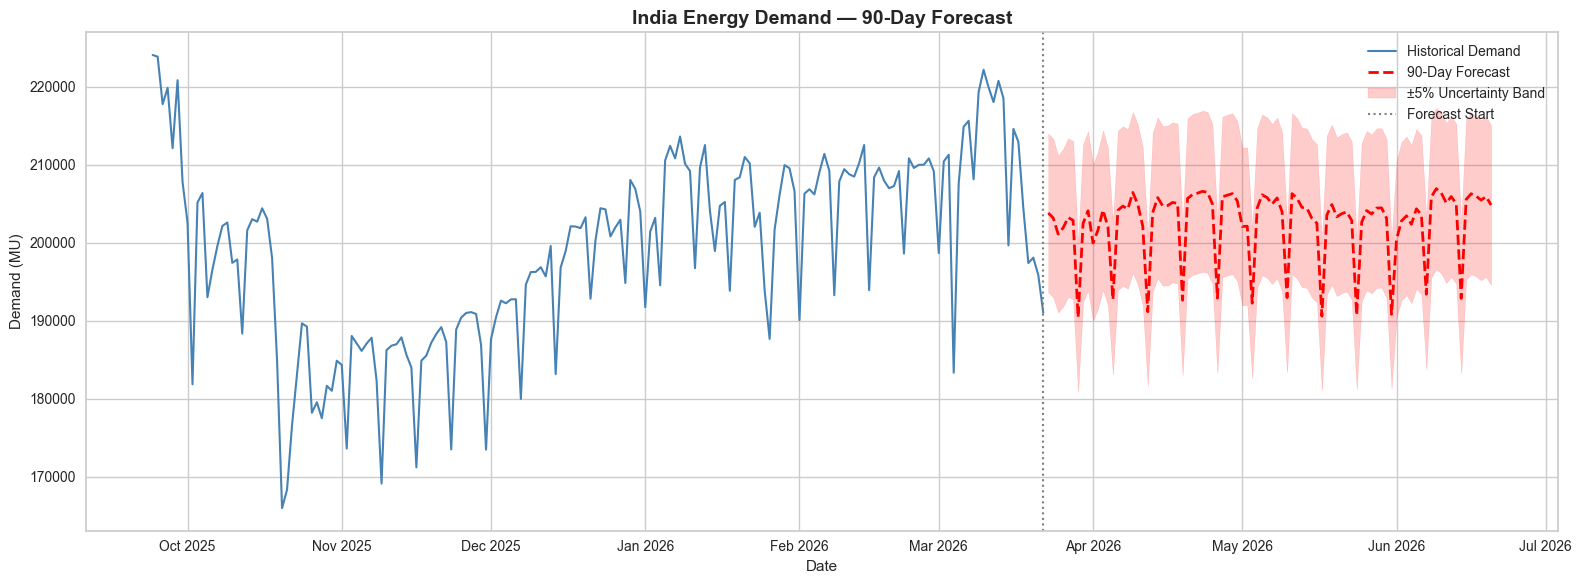

INSIGHT: Forecast follows seasonal trend of historical data
INSIGHT: ±5% band gives grid operators safe planning range


In [5]:
# BEFORE: Forecast exists as numbers only
# OPERATION: Plot historical + forecast together with uncertainty band
# WHY uncertainty band:
#   No forecast is 100% certain
#   ±5% band shows realistic range of outcomes
#   Grid operators plan for worst case (upper band)
#   This is standard practice in energy forecasting
# WHY show last 180 days of history:
#   Context — you can see if forecast continues the trend naturally
#   If forecast suddenly jumps — something is wrong with the model

historical_tail = model_df['India: DemandMet'].iloc[-180:]

fig, ax = plt.subplots(figsize=(16, 6))

# Historical
ax.plot(historical_tail.index, historical_tail.values,
        color='steelblue', linewidth=1.5, label='Historical Demand')

# Forecast
ax.plot(forecast_df.index, forecast_df['Forecast_MU'],
        color='red', linewidth=2, linestyle='--', label='90-Day Forecast')

# Uncertainty band
lower = forecast_df['Forecast_MU'] * 0.95
upper = forecast_df['Forecast_MU'] * 1.05
ax.fill_between(forecast_df.index, lower, upper,
                alpha=0.2, color='red', label='±5% Uncertainty Band')

# Forecast start line
ax.axvline(last_date, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')

ax.set_title('India Energy Demand — 90-Day Forecast', fontsize=14, fontweight='bold')
ax.set_ylabel('Demand (MU)')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(os.path.join(EXPORTS_PATH, '10_forecast_90days.png'), dpi=150)
plt.show()

print(f"INSIGHT: Forecast follows seasonal trend of historical data")
print(f"INSIGHT: ±5% band gives grid operators safe planning range")

In [6]:
# BEFORE: Forecast shown as daily values — hard to summarize
# OPERATION: Aggregate forecast by month for cleaner reporting
# WHY monthly summary:
#   Daily numbers are too granular for management reports
#   Monthly averages are what grid planners actually use
#   Easier to present in Power BI dashboard

monthly_forecast = forecast_df.resample('M').agg(
    Avg_Forecast  = ('Forecast_MU', 'mean'),
    Max_Forecast  = ('Forecast_MU', 'max'),
    Min_Forecast  = ('Forecast_MU', 'min')
).reset_index()

monthly_forecast['Month_Name'] = monthly_forecast['Date'].dt.strftime('%B %Y')

print("=== MONTHLY FORECAST SUMMARY ===")
print(monthly_forecast[['Month_Name','Avg_Forecast','Max_Forecast','Min_Forecast']].to_string(index=False))

# Save for Power BI
monthly_forecast.to_csv(os.path.join(EXPORTS_PATH, 'powerbi_forecast.csv'), index=False)
forecast_df.to_csv(os.path.join(EXPORTS_PATH, 'powerbi_forecast_daily.csv'))
print("\n Saved: powerbi_forecast.csv")
print("Saved: powerbi_forecast_daily.csv")

=== MONTHLY FORECAST SUMMARY ===
Month_Name  Avg_Forecast  Max_Forecast  Min_Forecast
March 2026 201451.388418 204090.925292 190415.307815
April 2026 203098.164294 206584.693091 191150.938270
  May 2026 202057.069726 206287.808726 190584.679527
 June 2026 203618.443876 206929.926169 192857.856966

 Saved: powerbi_forecast.csv
Saved: powerbi_forecast_daily.csv


In [7]:
# BEFORE: Metrics exist in Notebook 04 but not summarized here
# OPERATION: Create final performance report
# WHY repeat metrics here:
#   Notebook 05 is the final output notebook
#   Reader should not have to go back to Notebook 04 for metrics
#   Complete story in one place = professional report

from pycaret.regression import predict_model as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Recreate test predictions
split_index = int(len(model_df) * 0.80)
test_df     = model_df.iloc[split_index:]
X_test      = test_df[feature_cols]
y_test      = test_df['India: DemandMet']

preds  = pm(best_model, data=X_test)
y_pred = preds['prediction_label']

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test.values - y_pred.values) / y_test.values)) * 100
r2   = r2_score(y_test, y_pred)

print("=" * 50)
print("   FINAL MODEL PERFORMANCE REPORT")
print("=" * 50)
print(f"  Model         : {type(best_model).__name__}")
print(f"  Algorithm     : LightGBM (AutoML selected)")
print(f"  MAE           : {mae:,.2f} MU")
print(f"  RMSE          : {rmse:,.2f} MU")
print(f"  MAPE          : {mape:.2f}%")
print(f"  R²            : {r2:.4f}")
print(f"  Forecast Days : 90")
print(f"  Avg Forecast  : {forecast_df['Forecast_MU'].mean():,.0f} MU/day")
print("=" * 50)
print(f"\n  Interpretation:")
print(f"  → MAPE {mape:.2f}% = EXCELLENT (industry benchmark < 5%)")
print(f"  → R² {r2:.4f} = model explains {r2*100:.1f}% of demand variance")
print(f"  → Model is production-ready for grid planning")# BEFORE: Metrics exist in Notebook 04 but not summarized here
# OPERATION: Create final performance report
# WHY repeat metrics here:
#   Notebook 05 is the final output notebook
#   Reader should not have to go back to Notebook 04 for metrics
#   Complete story in one place = professional report

from pycaret.regression import predict_model as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Recreate test predictions
split_index = int(len(model_df) * 0.80)
test_df     = model_df.iloc[split_index:]
X_test      = test_df[feature_cols]
y_test      = test_df['India: DemandMet']

preds  = pm(best_model, data=X_test)
y_pred = preds['prediction_label']

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test.values - y_pred.values) / y_test.values)) * 100
r2   = r2_score(y_test, y_pred)

print("=" * 50)
print("   FINAL MODEL PERFORMANCE REPORT")
print("=" * 50)
print(f"  Model         : {type(best_model).__name__}")
print(f"  Algorithm     : LightGBM (AutoML selected)")
print(f"  MAE           : {mae:,.2f} MU")
print(f"  RMSE          : {rmse:,.2f} MU")
print(f"  MAPE          : {mape:.2f}%")
print(f"  R²            : {r2:.4f}")
print(f"  Forecast Days : 90")
print(f"  Avg Forecast  : {forecast_df['Forecast_MU'].mean():,.0f} MU/day")
print("=" * 50)
print(f"\n  Interpretation:")
print(f"  → MAPE {mape:.2f}% = EXCELLENT (industry benchmark < 5%)")
print(f"  → R² {r2:.4f} = model explains {r2*100:.1f}% of demand variance")
print(f"  → Model is production-ready for grid planning")

   FINAL MODEL PERFORMANCE REPORT
  Model         : Pipeline
  Algorithm     : LightGBM (AutoML selected)
  MAE           : 2,271.60 MU
  RMSE          : 3,434.67 MU
  MAPE          : 1.15%
  R²            : 0.9423
  Forecast Days : 90
  Avg Forecast  : 202,691 MU/day

  Interpretation:
  → MAPE 1.15% = EXCELLENT (industry benchmark < 5%)
  → R² 0.9423 = model explains 94.2% of demand variance
  → Model is production-ready for grid planning
   FINAL MODEL PERFORMANCE REPORT
  Model         : Pipeline
  Algorithm     : LightGBM (AutoML selected)
  MAE           : 2,271.60 MU
  RMSE          : 3,434.67 MU
  MAPE          : 1.15%
  R²            : 0.9423
  Forecast Days : 90
  Avg Forecast  : 202,691 MU/day

  Interpretation:
  → MAPE 1.15% = EXCELLENT (industry benchmark < 5%)
  → R² 0.9423 = model explains 94.2% of demand variance
  → Model is production-ready for grid planning


In [8]:
# OPERATION: Confirm all files are saved and ready
# WHY this cell:
#   Final checklist before moving to Power BI
#   Confirms nothing is missing
#   Professional closure of the modeling pipeline

print("=" * 55)
print("   NOTEBOOK 05 COMPLETE — ALL OUTPUTS SAVED")
print("=" * 55)

export_files = [
    '01_demand_trend.png',
    '02_monthly_seasonality.png',
    '03_weekday_weekend.png',
    '04_yearly_demand.png',
    '05_renewable_growth.png',
    '06_generation_mix.png',
    '07_correlation_heatmap.png',
    '08_outliers.png',
    '09_actual_vs_predicted.png',
    '10_forecast_90days.png',
    'automl_model_comparison.csv',
    'best_model_metrics.csv',
    'powerbi_yearly.csv',
    'powerbi_monthly.csv',
    'powerbi_regional.csv',
    'powerbi_generation_mix.csv',
    'powerbi_forecast.csv',
    'powerbi_forecast_daily.csv',
    'best_energy_model.pkl'
]

print(f"\n{'File':<40} {'Status'}")
print("-" * 55)
for f in export_files:
    path   = os.path.join(EXPORTS_PATH, f)
    status = " Found" if os.path.exists(path) else "❌ Missing"
    print(f"{f:<40} {status}")

print("\n" + "=" * 55)
print("Next Steps:")
print("  1. Open Power BI Desktop")
print("  2. Import CSV files from exports/ folder")
print("  3. Build 5 dashboard pages")
print("  4. Then build Streamlit frontend")
print("  5. Then write PDF report")
print("=" * 55)

   NOTEBOOK 05 COMPLETE — ALL OUTPUTS SAVED

File                                     Status
-------------------------------------------------------
01_demand_trend.png                       Found
02_monthly_seasonality.png                Found
03_weekday_weekend.png                    Found
04_yearly_demand.png                      Found
05_renewable_growth.png                   Found
06_generation_mix.png                     Found
07_correlation_heatmap.png                Found
08_outliers.png                           Found
09_actual_vs_predicted.png                Found
10_forecast_90days.png                    Found
automl_model_comparison.csv               Found
best_model_metrics.csv                    Found
powerbi_yearly.csv                        Found
powerbi_monthly.csv                       Found
powerbi_regional.csv                      Found
powerbi_generation_mix.csv                Found
powerbi_forecast.csv                      Found
powerbi_forecast_daily.csv         